# 手写数字识别
框架：Pytorch

## 手写数字识别的基本原理
- 手写数字识别是一种计算机视觉任务，旨在识别和分类手写的数字图像。
- 该任务通常使用机器学习和深度学习技术，通过训练神经网络来学习数字的特征和模式。
- 手写数字识别的基本流程包括数据预处理、特征提取、模型训练和评估等步骤。
- 本实验使用自己构建的简单神经网络模型和训练集来实现手写数字识别，展示了神经网络在图像分类任务中的应用。
- 由于复杂性，本次仅使用简单的神经网络模型，实际应用中通常使用卷积神经网络（CNN）等更复杂的模型以提高识别准确率。

**导入所需的库**

In [1]:
# 导入必要的库
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

### 步骤1：准备数据集

在./data/目录下，有`X.npy`和`y.npy`两个文件，分别存储手写数字图像数据和对应的标签。

In [2]:
# 加载数据集
X = np.load('./data/X.npy')
y = np.load('./data/y.npy')

# 显示数据的形状
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 400)
y shape: (5000, 1)


可以发现输出为：
```
X shape: (5000, 400)
y shape: (5000, 1)
```
这表示我们有5000个样本，每个样本是一个400维的向量（20x20像素的图像展开成一维），对应的标签是一个5000x1的向量，表示每个样本的数字类别（0-9）。

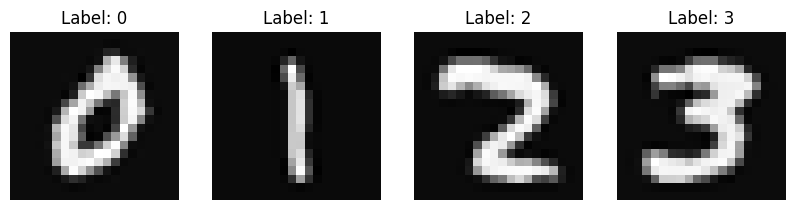

In [3]:
# 可视化部分数据
def visualize_data(X, y, num_samples=4):
    plt.figure(figsize=(10, 110))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(X[i* 500 + 3].reshape(20, 20).T, cmap='gray')
        plt.title(f"Label: {y[i* 500 + 3][0]}")
        plt.axis('off')
    plt.show()

visualize_data(X, y)

### 步骤2：定义神经网络模型

主要包括输入层、隐藏层和输出层。

具体的结构如下：
- 输入层：400个神经元（对应20x20像素的图像），无激活函数
- 隐藏层：使用ReLU激活函数。总共设计了5个隐藏层，神经元的数量均为25个
- 输出层：10个神经元，使用Softmax激活函数（对应数字0-9的类别）

In [4]:
# 定义神经网络模型
class HandwritingRecognitionModel(nn.Module):
    def __init__(self):
        super(HandwritingRecognitionModel, self).__init__()
        # 5个隐藏层，每层25个神经元
        self.network = nn.Sequential(
            nn.Linear(400, 25),
            nn.ReLU(),
            nn.Linear(25, 25),
            nn.ReLU(),
            nn.Linear(25, 25),
            nn.ReLU(),
            nn.Linear(25, 25),
            nn.ReLU(),
            nn.Linear(25, 25),
            nn.ReLU(),
            nn.Linear(25, 10)  # 输出层，10个神经元
        )

    # 重要：定义前向传播过程
    def forward(self, x):
        x = self.network(x)
        return x

### 步骤3：训练模型

使用交叉熵损失函数和Adam优化器进行训练。

In [5]:
# 准备数据
# 将数据划分为训练集和测试集
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train.flatten())
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test.flatten())

# 创建数据集和数据加载器
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

# 初始化模型、损失函数和优化器
model = HandwritingRecognitionModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 训练模型
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_dataloader:
        inputs = inputs.view(-1, 400)  # 展平输入
        # 前向传播和反向传播
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {running_loss / len(train_dataloader):.4f}")

Epoch [10/100], Loss: 0.3752
Epoch [20/100], Loss: 0.1742
Epoch [30/100], Loss: 0.0946
Epoch [40/100], Loss: 0.0525
Epoch [50/100], Loss: 0.0458
Epoch [60/100], Loss: 0.0458
Epoch [70/100], Loss: 0.0031
Epoch [80/100], Loss: 0.0081
Epoch [90/100], Loss: 0.0015
Epoch [100/100], Loss: 0.0007


### 步骤4：评估模型

主要包括计算模型在测试集上的准确率，并展示部分预测结果。

Test Accuracy: 0.9160


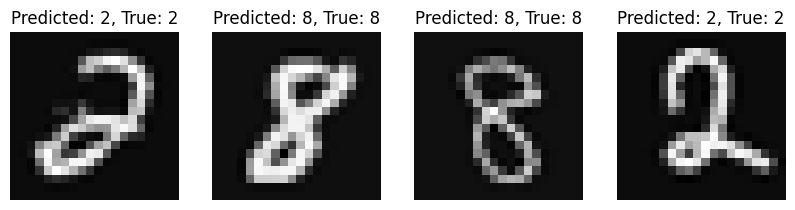

In [7]:
# 评估模型，并计算准确率
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs = inputs.view(-1, 400)  # 展平输入
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {correct / total:.4f}")

# 可视化部分预测结果
def visualize_predictions(model, X_test, y_test, num_samples=4):
    model.eval()
    plt.figure(figsize=(10, 110))
    with torch.no_grad():
        for i in range(num_samples):
            plt.subplot(1, num_samples, i + 1)
            input_tensor = torch.FloatTensor(X_test[i * 100 + 3]).view(-1, 400)
            output = model(input_tensor)
            _, predicted = torch.max(output.data, 1)
            plt.imshow(X_test[i * 100 + 3].reshape(20, 20).T, cmap='gray')
            plt.title(f"Predicted: {predicted.item()}, True: {y_test[i * 100 + 3][0]}")
            plt.axis('off')
    plt.show()

visualize_predictions(model, X_test, y_test)

## 总结
- 本实验展示了如何使用简单的神经网络模型实现手写数字识别任务。
- 通过定义模型结构、训练过程和评估方法，展示了神经网络在图像分类中的应用。
- 实际应用中，通常会使用更复杂的模型（如卷积神经网络）和更大的数据集以提高识别准确率。